# Trading game #2 - Beating Passive Strategies in the Bullish Commodity Markets - Rice commodity


**GAUSSIN Natacha**

**FOURREAU Mathis**

*ESILV IF3 - Commodities Markets and Models*
 
**Reference:** Palazzi, Rafael Baptista. (2025). *Trading Games: Beating Passive Strategies in the Bullish Crypto Market*. Journal of Futures Markets, Wiley.  

## 1. Introduction

This project examines the effectiveness of cointegrated pairs trading in commodities markets, especially in rice market.introducing systematic
parameter optimization within the trading framework. The analysis is conducted using a dataset comprising more than 20 assets relating to rice activities, The methodology incorporates dynamic risk management through adaptive trailing stop‐loss and volatility filtering
mechanisms. The different results of our project demonstrate that the pairs trading strategy consistently outperforms index based passive approaches, generating significant risk‐adjusted excess returns, while maintaining low market exposure.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron
from scipy.stats import kurtosis, skew
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import matplotlib.pyplot as plt
from itertools import product
import yfinance as yf
import seaborn as sns
import matplotlib.dates as mdates


## 2. Methodology
1. **Data loading & transformation** — log-prices and log-returns across 15 rice-related assets
2. **Stationarity tests** — ADF and Phillips-Perron to confirm each series is I(1)
3. **Cointegration test** — Johansen procedure on all possible pairs, selected at the 95% confidence level
4. **Relationship estimation** — Engle-Granger method (OLS) to estimate $\mu$ and $\gamma$ on training data only
5. **Spread & Z-score** — normalized spread and rolling Z-score to generate trading signals
6. **Risk management** — volatility filter (avoids trading during extreme market conditions) + dynamic trailing stop adjusted to current volatility
7. **Parameter optimization** — grid search over lookback, thresholds, L_v, k, base_stop using Sharpe ratio (train only, no data leakage)
8. **Performance evaluation** — Sharpe, Calmar, annual return, volatility, max drawdown on the test set. comparison against a passive benchmark and classical strategies

## 3. Data Importation

All data used in this study are obtained from the yfinance API. This section is mainly included for reproducibility purposes. In case of any issues with the yfinance API, a fully processed version of the dataset is loaded at the end of Section 3 (with the file data.csv).

**The Primary Anchor (1 asset)**: 

- rough rice futures

**The Sector Proxies (4 assets): Relevant ETFs to capture broader sector beta**
- Invesco DB Agriculture Fund, DBA
- iPath Bloomberg Grains ETN, JJG
- Elements Rogers International Agriculture ETN, RJA
- WisdomTree Grains ETF, 1688.T

**The Individual Universe (17 assets): companies
directly involved in the commodity’s value chain**


- KRBL Limited, KRBL.NS – Indian company specializing in basmati rice production and export
- LT Foods Limited, LTFOODS.NS – Indian rice producer and owner of the Daawat basmati brand
- Chaman Lal Setia Exports Ltd, CLSEL.NS – Indian exporter of basmati rice
- Kohinoor Foods Ltd, KOHINOOR.NS – Indian basmati rice producer and exporter
- Archer Daniels Midland Company, ADM – Global agribusiness and grain trading company
- Bunge Global SA, BG – Multinational agribusiness and food company specializing in grain trading
- Olam Group Ltd, VC2.SI  – Singapore-based agricultural commodity trader involved in rice and other crops
- Village Farms International Inc, VFF  – Agricultural producer focused on controlled-environment farming
- Nutrien Ltd, NTR – Canadian agricultural input company and fertilizer producer supporting global crop production
- Mosaic Company, MOS – Major producer of phosphate and potash fertilizers used in agriculture
- CF Industries Holdings Inc, CF – Global manufacturer of nitrogen fertilizers for crop production
- Adecoagro SA, AGRO – Agricultural production company operating farms and food processing in South America
- Fresh Del Monte Produce Inc, FDP – Global agricultural company involved in food production and distribution
- Yara International ASA, YAR.OL – Norwegian fertilizer company playing a key role in global agricultural productivity
- Ingredion Incorporated, INGR – US-based producer of starches and food ingredients derived from agricultural commodities
- Itochu Corporation, 8001.T – Japanese trading house with strong involvement in global agricultural and food supply chains
- BrasilAgro – Companhia Brasileira de Propriedades Agrícolas, AGRO3.SA (yfinance) – Brazilian company focused on farmland development and agricultural production


In [ ]:

anchor = [
    "ZR=F"
]


sector_proxies = [
    "DBA",         
    "RJA",     
    "1688.T"   
]

companies = [
    "KRBL.NS",
    "LTFOODS.NS",
    "CLSEL.NS",
    "ADM",
    "BG",
    "VC2.SI",
    "VFF",
    "NTR",
    "MOS",
    "CF",
    "AGRO",
    "FDP",
    "YAR.OL",   
    "INGR",     
    "8001.T",   
    "AGRO3.SA" 
]

In [ ]:
tickers = anchor + sector_proxies + companies

data = yf.download(tickers, start="2018-01-01", end="2026-03-28", progress=False)

close_prices = data["Close"]

print(close_prices.head())

Ticker      1688.T      8001.T        ADM      AGRO  AGRO3.SA         BG  \
Date                                                                       
2018-01-01   395.0  326.628387        NaN       NaN       NaN        NaN   
2018-01-02   395.0  326.628387  31.407618  9.198833  6.842368  52.966415   
2018-01-03   395.0  326.628387  31.164761  9.394551  6.836969  54.103798   
2018-01-04   399.0  334.860168  31.689669  9.350069  7.058386  54.898426   
2018-01-05   390.0  337.034546  31.478142  9.207728  7.204200  54.485538   

Ticker             CF  CLSEL.NS        DBA        FDP        INGR     KRBL.NS  \
Date                                                                            
2018-01-01        NaN       NaN        NaN        NaN         NaN  556.974548   
2018-01-02  35.073044       NaN  16.306484  39.298061  111.920692  555.493774   
2018-01-03  35.081184       NaN  16.297888  39.524158  110.449440  560.167542   
2018-01-04  35.447037       NaN  16.272102  40.353149  112.624

In [ ]:
#anchor["Date"] = pd.to_datetime(anchor["Date"], dayfirst=True)
#anchor["Dernier"] = anchor["Dernier"].str.replace(",", ".").astype(float)
#anchor = anchor.set_index("Date")

#anchor_close = anchor["Dernier"].rename("Futures")

anchor_close = anchor["Close"]

close_prices = close_prices.join(anchor_close)

df_raw = close_prices.copy()
df_raw = df_raw.rename(columns={"ZR=F": "Futures"})

#### Data Exploration

This step aims to give a clear overview of the raw data. This overview will be particularly useful to understand the data and prepare the cleaning part.

In [ ]:
def plot_missing_proportions(
    df: pd.DataFrame,
    title: str = "Missing value proportion by asset"
) -> pd.Series:
    """
    Plot the proportion of missing values for each column in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    title : str
        Plot title.

    Returns
    -------
    pd.Series
        Missing value proportions by column.
    """
    if df.empty:
        raise ValueError("The input DataFrame is empty.")

    missing_prop = df.isna().mean().sort_values(ascending=False)

    ax = missing_prop.plot(kind="bar", figsize=(12, 6))
    ax.set_title(title)
    ax.set_xlabel("Assets")
    ax.set_ylabel("Missing value proportion")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", alpha=0.3)

    for i, value in enumerate(missing_prop):
        ax.text(i, value + 0.02, f"{value:.1%}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    return missing_prop

def price_visualization(df: pd.DataFrame, title: str = "Asset price trends") -> None:
    # Normalize all prices to 100 at the start of the period for comparison.
    first_valid = df.apply(lambda col: col[col.notna()].iloc[0])
    df_norm = df / first_valid * 100

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # --- Plot 1: Raw prices ---
    for col in df.columns:
        axes[0].plot(df.index, df[col], label=col, linewidth=1.2)
    axes[0].set_title('Raw Prices (2020–2026)', fontsize=13)
    axes[0].set_ylabel('Price (USD or local currency)')
    axes[0].legend(fontsize=9)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # --- Plot 2: Normalized prices (rebased to 100) ---
    for col in df_norm.columns:
        axes[1].plot(df_norm.index, df_norm[col], label=col, linewidth=1.2)
    axes[1].axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[1].set_title('Normalized Prices (rebased to 100 at start)', fontsize=13)
    axes[1].set_ylabel('Index (base = 100)')
    axes[1].legend(fontsize=9)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

In [ ]:
print(f"Dataset shape: {df_raw.shape}  ({df_raw.shape[0]} trading days, {df_raw.shape[1]} assets)")
print(f"Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}")
print()
print("Columns (assets):")
print(list(df_raw.columns))

Dataset shape: (2153, 20)  (2153 trading days, 20 assets)
Date range: 2018-01-01 → 2026-03-27

Columns (assets):
['1688.T', '8001.T', 'ADM', 'AGRO', 'AGRO3.SA', 'BG', 'CF', 'CLSEL.NS', 'DBA', 'FDP', 'INGR', 'KRBL.NS', 'LTFOODS.NS', 'MOS', 'NTR', 'RJA', 'VC2.SI', 'VFF', 'YAR.OL', 'Futures']


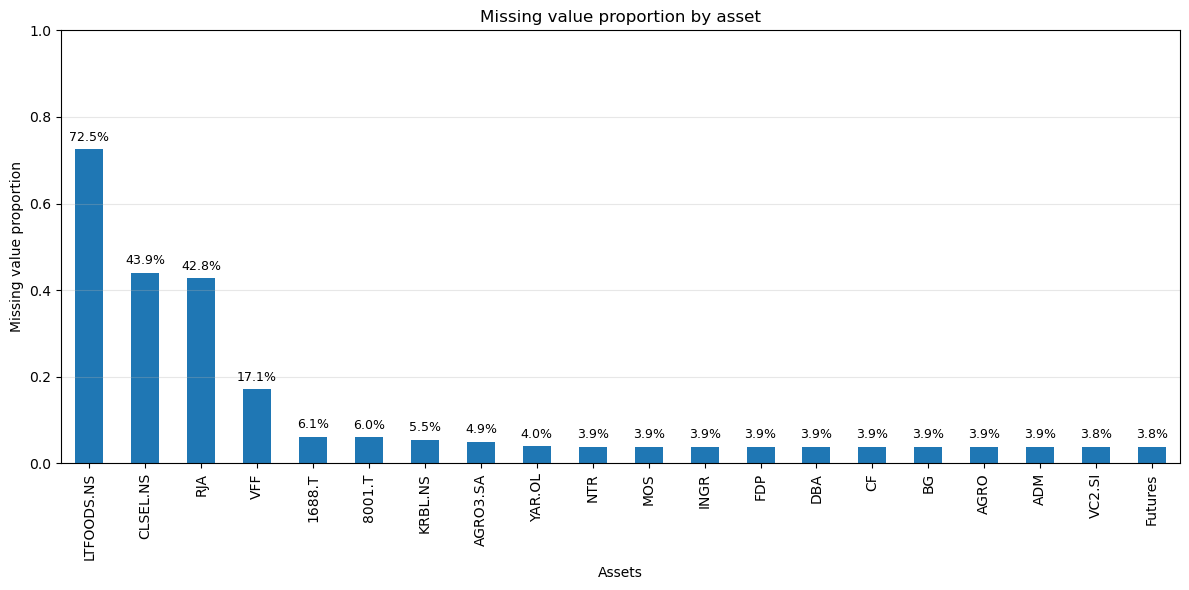

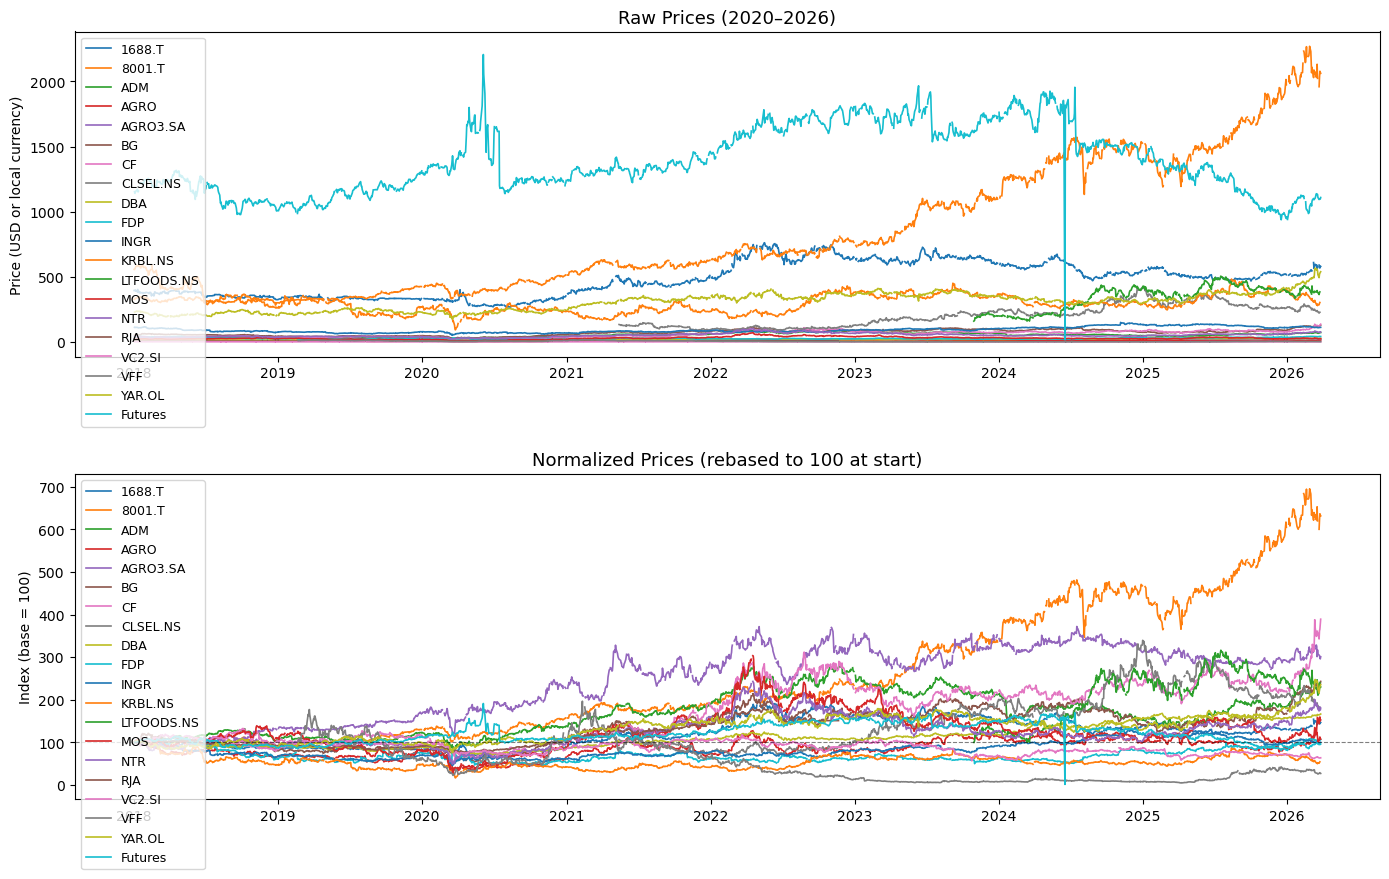

In [ ]:
plot_missing_proportions(df_raw)
price_visualization(df_raw)

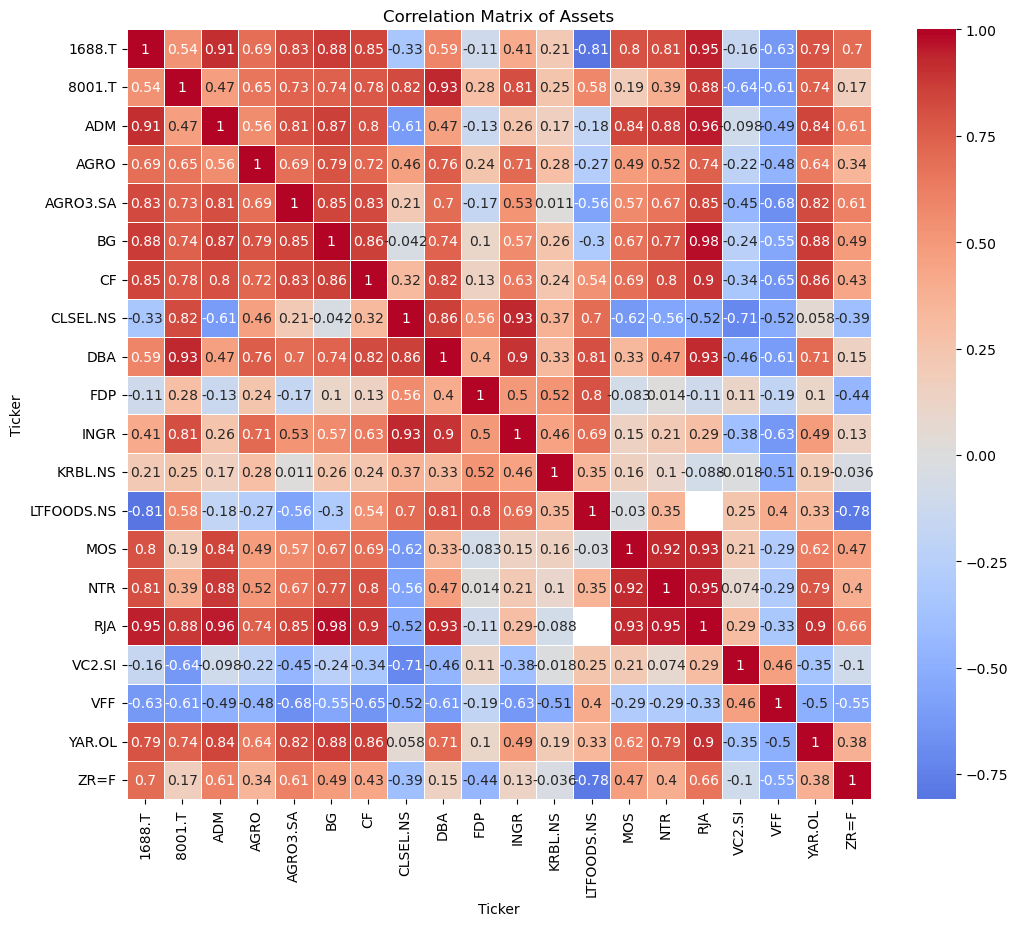

In [ ]:
corr_matrix = close_prices.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Assets")
plt.show()

#### Data Cleaning

In [ ]:
# ==========================
# GLOBAL VARIABLES
# ==========================

START = '2018-01-01'

**Keep rows where the Futures is available**

`Futures` variable contains NaN values up until 2020. Thus we will start our dataset from this date. Having values up to 2026. We still keep more than 5 years of data in our dataset. 

In [ ]:
# ==========================
# DATA CLEANING
# ==========================

ANCHOR = 'Futures'
df = df_raw[df_raw[ANCHOR].notna()].copy()
df = df[df.index >= START]

print(f"After anchor filter — shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print()

After anchor filter — shape: (2071, 20)
Date range: 2018-01-02 → 2026-03-27



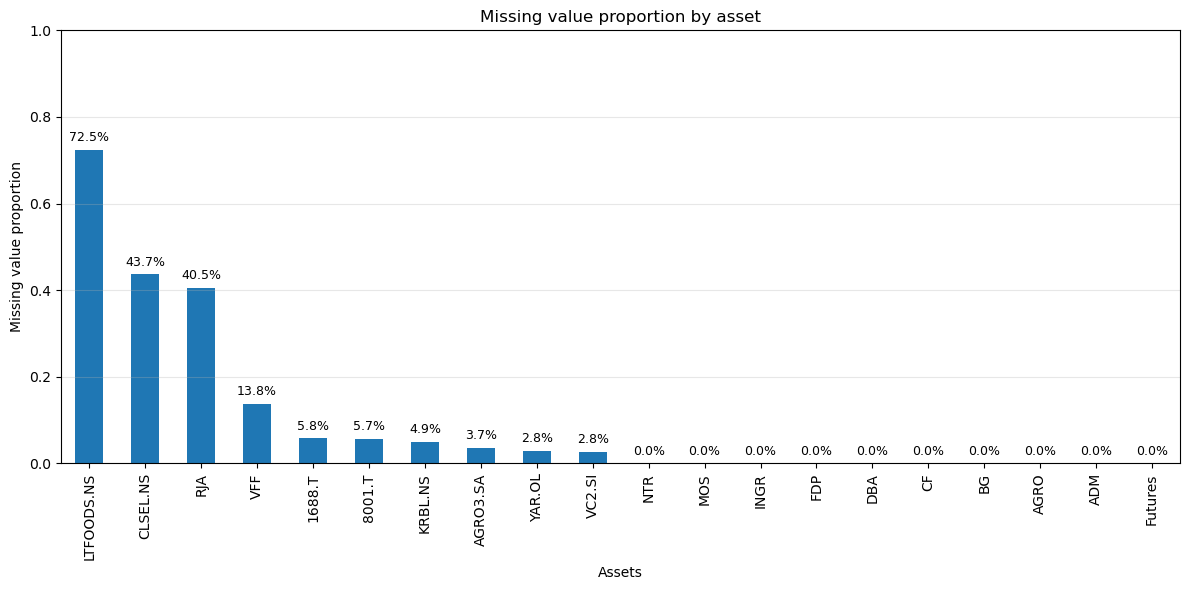

Ticker
LTFOODS.NS    0.724771
CLSEL.NS      0.436987
RJA           0.405118
VFF           0.138098
1688.T        0.058426
8001.T        0.057460
KRBL.NS       0.049252
AGRO3.SA      0.036697
YAR.OL        0.028489
VC2.SI        0.027523
NTR           0.000483
MOS           0.000483
INGR          0.000483
FDP           0.000483
DBA           0.000483
CF            0.000483
BG            0.000483
AGRO          0.000483
ADM           0.000483
Futures       0.000000
dtype: float64

In [ ]:
plot_missing_proportions(df)

**Drop assets with more than 20% missing values**

In [ ]:
MISSING_THRESHOLD = 0.20
missing_pct = df.isnull().mean()
print("Missing value rate per asset:")
print(missing_pct.round(4).to_frame('Missing %').to_string())
print()

assets_to_keep = missing_pct[missing_pct <= MISSING_THRESHOLD].index.tolist()
assets_dropped = missing_pct[missing_pct >  MISSING_THRESHOLD].index.tolist()

print(f"Assets dropped (>{MISSING_THRESHOLD*100:.0f}% missing): {assets_dropped}")
print(f"Assets retained for screening: {assets_to_keep}")
print()

df = df[assets_to_keep].copy()

Missing value rate per asset:
            Missing %
Ticker               
1688.T         0.0584
8001.T         0.0575
ADM            0.0005
AGRO           0.0005
AGRO3.SA       0.0367
BG             0.0005
CF             0.0005
CLSEL.NS       0.4370
DBA            0.0005
FDP            0.0005
INGR           0.0005
KRBL.NS        0.0493
LTFOODS.NS     0.7248
MOS            0.0005
NTR            0.0005
RJA            0.4051
VC2.SI         0.0275
VFF            0.1381
YAR.OL         0.0285
Futures        0.0000

Assets dropped (>20% missing): ['CLSEL.NS', 'LTFOODS.NS', 'RJA']
Assets retained for screening: ['1688.T', '8001.T', 'ADM', 'AGRO', 'AGRO3.SA', 'BG', 'CF', 'DBA', 'FDP', 'INGR', 'KRBL.NS', 'MOS', 'NTR', 'VC2.SI', 'VFF', 'YAR.OL', 'Futures']



**Forward-fill remaining NaNs**

In [ ]:
# Step 3: Forward-fill remaining NaNs (align trading days across markets)
# then drop any residual NaN rows
df = df.ffill().dropna()

# Make sure the anchor is still present
assert ANCHOR in df.columns, f"ERROR: Anchor '{ANCHOR}' was dropped — lower MISSING_THRESHOLD."

ALL_ASSETS = list(df.columns)   # full universe passed to screening

print(f"All selected assets for Section 3 screening: {ALL_ASSETS}")

All selected assets for Section 3 screening: ['1688.T', '8001.T', 'ADM', 'AGRO', 'AGRO3.SA', 'BG', 'CF', 'DBA', 'FDP', 'INGR', 'KRBL.NS', 'MOS', 'NTR', 'VC2.SI', 'VFF', 'YAR.OL', 'Futures']


**Outliers**

##### Why handle the outliers?

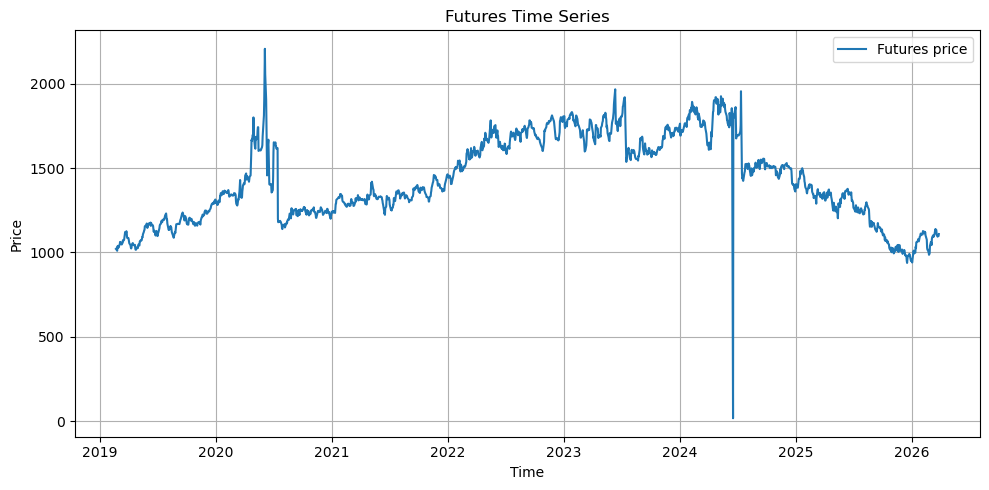

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(df["Futures"], label="Futures price")

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Futures Time Series")
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

As we can observe, there are some abnormal price variations, such as in 2024 where the futures price drops close to zero. Such anomalies can have a significant and unrealistic impact on trading strategies.

To address this issue, we identify several types of outliers:

- extrem absolute returns (above 50%),
- price glitches, such as isolated patterns where the price moves from 1000 to 0 and then returns to 1000.

After detecting these outlier, and in order to preserve the overall price dynamics, we correct them by replacing the abnormal value with the average of the surrounding prices (the prices immediately before and after the outlier).

The following code implements this procedure.

In [ ]:
def clean_price(price, max_return=0.5):
    
    price = price.copy()
    
    returns = price.pct_change()
    outlier_mask = np.abs(returns) > max_return
    
    for i in range(1, len(price)-1):
        
        if outlier_mask.iloc[i]:
            
            prev_p = price.iloc[i-1]
            next_p = price.iloc[i+1]
            
            if np.isfinite(prev_p) and np.isfinite(next_p) and prev_p > 0 and next_p > 0:
                
                price.iloc[i] = (prev_p + next_p) / 2
    
    return price

In [ ]:
df = df.apply(clean_price)

**Price visualization**

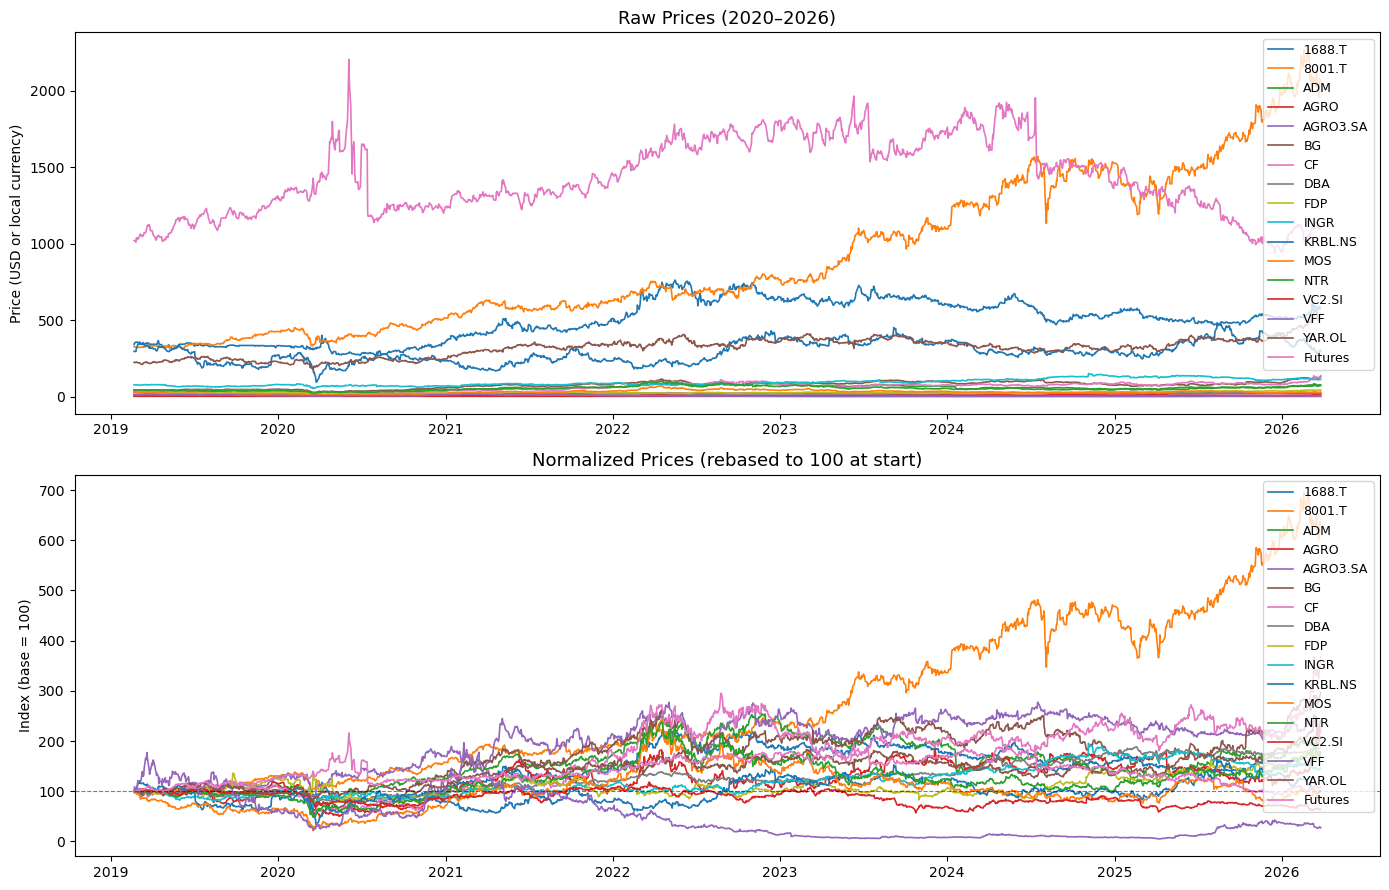

In [ ]:
price_visualization(df)

**Data Saving**

In [ ]:
df.to_csv("data.csv")

**Loading the dataset**

As mentioned previously, we provide a preprocessed dataset named "data.csv". The previous section was included for reproducibility purposes. We now load the local dataset for the subsequent analysis.



In [ ]:
try:
    df_prices = pd.read_csv("data.csv") #local dataset

except FileNotFoundError:
    df_prices = df

We transform prices into logarithmic scale in order to compute log-returns, ensuring consistency with our reference framework.

In [224]:
log_prices = np.log(df_prices.iloc[:, 1:])
log_returns = log_prices.diff()

## 4. Cointegration tests

First recall the definition of cointegration from the course

Cointegration: Two or more non-stationary series share a common
stochastic trend. A linear combination of them is stationary.

Statistical Interpretation: Deviation from equilibrium are mean-reverting


##### **Testing for Cointegration: The Johansen Procedure**

**Step 1: Confirm both series are I(1) (unit root tests)**

That means that the serie of price is not stationnary but its increment process are. For that purpose we can use Augmented Dickey-Fuller (ADF) or Phillips-Perron (PP) test.

In [225]:
def compute_stats(data):

    results = []

    for col in data.columns:
        
        series = data[col].dropna()

        adf_p = adfuller(series)[1]
        pp_p = PhillipsPerron(series).pvalue
        
        mean = series.mean()
        std = series.std()
        min_v = series.min()
        max_v = series.max()
        kurt = kurtosis(series)
        skewness = skew(series)

        results.append([col,round(adf_p,3),round(pp_p,3),round(mean,3),round(std,3),round(min_v,3),round(max_v,3),round(kurt,3),round(skewness,3)])

    columns = ["Symbol","ADF test","PP test","Mean","Std","Min","Max","Kurtosis","Skewness"]

    return pd.DataFrame(results, columns=columns)

levels_table = compute_stats(log_prices)
returns_table = compute_stats(log_returns)

print("LEVELS")
levels_table

LEVELS


,Symbol,ADF test,PP test,Mean,Std,Min,Max,Kurtosis,Skewness
0,1688.T,0.667,0.621,6.171,0.282,5.591,6.636,-1.052,-0.414
1,8001.T,0.920,0.941,6.656,0.548,5.739,7.728,-1.219,0.081
2,ADM,0.521,0.549,3.964,0.291,3.206,4.477,-0.894,-0.344
3,AGRO,0.552,0.454,2.035,0.295,1.150,2.688,0.287,-0.903
4,AGRO3.SA,0.243,0.239,2.856,0.302,2.116,3.237,-0.378,-0.987
5,BG,0.723,0.745,4.264,0.348,3.235,4.858,-0.453,-0.823
6,CF,0.835,0.856,4.072,0.428,2.906,4.916,-0.821,-0.623
7,DBA,0.946,0.951,2.900,0.241,2.452,3.310,-1.112,0.038
8,FDP,0.745,0.452,3.249,0.173,2.884,3.755,-0.055,0.705
9,INGR,0.658,0.669,4.501,0.233,3.936,5.011,-1.082,0.295


From this table, we observe that none of the price series are stationary, which is consistent with the literature. In the following section, we will examine the stationarity of the log-returns.

In [226]:
print("\nLOG RETURNS")
returns_table


LOG RETURNS


,Symbol,ADF test,PP test,Mean,Std,Min,Max,Kurtosis,Skewness
0,1688.T,0.0,0.0,0.000,0.017,-0.136,0.213,19.373,1.162
1,8001.T,0.0,0.0,0.001,0.016,-0.157,0.089,8.315,-0.344
2,ADM,0.0,0.0,0.000,0.019,-0.277,0.098,30.312,-2.199
3,AGRO,0.0,0.0,0.000,0.027,-0.261,0.133,9.665,-0.905
4,AGRO3.SA,0.0,0.0,0.000,0.018,-0.114,0.095,3.026,-0.144
5,BG,0.0,0.0,0.001,0.020,-0.154,0.135,6.494,-0.487
6,CF,0.0,0.0,0.001,0.025,-0.167,0.151,4.429,-0.320
7,DBA,0.0,0.0,0.000,0.009,-0.050,0.030,2.077,-0.363
8,FDP,0.0,0.0,0.000,0.023,-0.172,0.225,16.270,0.314
9,INGR,0.0,0.0,0.000,0.017,-0.151,0.144,17.492,-0.821


Every log returns are stationnary with p-value < 0.001. We can thus keep all the series of prices that seems to be I(1) ann then adapted to the cointegration test.

**Step 2: Test for cointegration using Johansen test**

In [227]:
assets = log_prices.columns
results = []

for i in range(len(assets)):
    
    for j in range(i+1, len(assets)):
        
        a = assets[i]
        b = assets[j]

        

        pair_df = log_prices[[a, b]].dropna()

        if len(pair_df) < 50:
            continue
        joh = coint_johansen(pair_df,det_order=0,k_ar_diff=1)

        trace_stat = joh.lr1[0]
        crit_95 = joh.cvt[0,1]

        cointegrated = trace_stat > crit_95
        results.append({"Asset 1": a,"Asset 2": b,"Trace Stat": trace_stat,"Critical 95%": crit_95,"Cointegrated": cointegrated})

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("Trace Stat", ascending=False)

cointegrated_pairs = results_df[results_df["Cointegrated"] == 1][["Asset 1", "Asset 2"]]

least_cointegrated = (results_df.sort_values(by="Trace Stat", ascending=True)[["Asset 1", "Asset 2"]].head(7))

**Remark**

The results below indicate that several pairs of assets are cointegrated, which suggests the presence of stable long-run relationships that can be exploited in a pair trading strategy. However, when focusing on our anchor asset, the rough rice future,we observe that it is cointegrated with only a limited number of other assets.

As a result, we choose to retain all identified cointegrated pairs for our trading strategy, rather than restricting ourselves solely to those involving the rice future.

The limited cointegration involving rough rice futures is not unexpected. Unlike more globally traded commodities such as oil or gas, rice markets tend to be more regionally segmented. Production, consumption, and pricing dynamics are often driven by local factors, such as domestic policies, weather conditions, and regional supply chains, rather than by global market integration. Consequently, rice prices may exhibit weaker long-term relationships with other commodities, leading to fewer cointegration opportunities.

We also retain a list of non-cointegrated pairs in order to compare the performance of pairs trading with such pairs.

In [228]:
#results of cointegration test
results_df

,Asset 1,Asset 2,Trace Stat,Critical 95%,Cointegrated
1,1688.T,ADM,21.726045,15.4943,True
46,AGRO,BG,18.698791,15.4943,True
4,1688.T,BG,18.008246,15.4943,True
10,1688.T,MOS,17.561960,15.4943,True
63,AGRO3.SA,KRBL.NS,17.462387,15.4943,True
...,...,...,...,...,...
16,8001.T,ADM,2.715888,15.4943,False
0,1688.T,8001.T,2.503254,15.4943,False
28,8001.T,VFF,2.467829,15.4943,False
97,DBA,VFF,2.452054,15.4943,False


**Step 3: If cointegrated, estimate the relationship**

For each cointegrated pairs there exist a cointegrated relationship of the following form:

$$
Y_{1,t} = \mu + \gamma Y_{2,t} + \varepsilon_t, \quad \varepsilon_t \sim I(0)
$$

where $\mu$ is the intercept,$\gamma$ is the cointegrating coefficient,and $\varepsilon_t$
is a stationary error term. To estimate we can use VECM estimation like in the course, but this method is less direct to obtain $\mu$ and $\gamma$, in our main reference they employ the Eagle and Granger method which is way more adapted in our situation.

### 5. Implementation of our strategy

In the next section, we will detail the different features used in our pair trading strategy. At the end of this part, we will present our pipeline, which brings together all the presented functions.

When dealing with a cointegrated pair the first step is to estimate their relation through the estimation of $\mu$ and $\gamma$. 

In [229]:
#This function aim to estimate the mu and gamma coefficient for a cointegrated pair
def estimate_coint_coeffs(Y):

    Y = Y.dropna().values
    Asset_1 = Y[:, 0]
    Asset_2 = Y[:, 1]

    X = np.column_stack([np.ones(len(Asset_2)), Asset_2])

    try:
        beta = np.linalg.lstsq(X, Asset_1, rcond=None)[0]
    except np.linalg.LinAlgError:
        return np.nan, np.nan

    mu = beta[0]
    gamma = beta[1]

    return mu, gamma


Afet that we can write the spread $S_t$:

$$
S_t = Y_{1,t} - \gamma Y_{2,t}
$$

and thus this spread is mean reverting and can be used for a trading strategy based on statistical arbitrage.


To generate trading signals, we normalize the spread by calculating the Z-score, which measures the spread's deviation from it's rolling mean, scaled by it's rolling standard deviation. The Z-score is defined as:

$$
Z_t = \frac{S_t - \mu_{S_t}}{\sigma_{S_t}}
$$

where $\mu_{S_t}$ is the spread's rolling mean over a lookback period $L$,and $\sigma_{S_t}$ is the rolling standard deviation of the spread over the same period.

In [230]:
# function that calculate the spread (normalized)

def spread(Y, gamma):
    vect_spread = (Y.iloc[:, 0] - gamma*Y.iloc[:, 1])/(1 + np.abs(gamma))
    return vect_spread

# fonction that calculate the Z-score

def Z_score(vect_spread, lookback):
    vect_Z_score = np.zeros(vect_spread.size - lookback)

    for i in range(vect_spread.size - lookback):
        vect_Z_score[i] = (vect_spread[lookback+i] - np.mean(vect_spread[i:i+lookback]))/(np.std(vect_spread[i:i+lookback]))
    return vect_Z_score


**Generate the trading signal**

We have 
$$
s_t =
\begin{cases}
1 & \text{if } Z_t \le \text{Threshold}_{Long} \\
-1 & \text{if } Z_t \ge \text{Threshold}_{Short} \\
0 & \text{otherwise}
\end{cases}
$$

$s_t$ represent the position taken at time t (1 for long, 0 for no position and -1 for short). The thresholds are dynamically ajusted based on rolling volatility.

In [231]:
def generate_signal(vect_Z_score, threshold_long, threshold_short):
    vect_signal = np.zeros(len(vect_Z_score))

    vect_signal[vect_Z_score <= threshold_long] = 1
    vect_signal[vect_Z_score >= threshold_short] = -1

    return vect_signal

**Compute the returns**

We first consider the classical return:

$$
R_t = \text{Signal}_{t-1} \cdot \Delta S_t 
$$

where $\text{Signal}_{t-1}$ correspond to the position at $t-1$ (it can of course be no position, in this case the return is 0).

In order to have a more realistic approach, we also consider transaction cost that we applie in case of change of position (change of signal). The return write now:

$$
R_t = \text{Signal}_{t-1} \cdot \Delta S_t - c \cdot |\Delta \text{Signal}_t|
$$



In [232]:
def compute_returns(vect_spread, signal, transaction_cost):

    spread_return = np.diff(vect_spread, prepend=np.nan)

    signal_lag = np.roll(signal, 1)
    signal_lag[0] = 0

    delta_signal = np.diff(signal, prepend=0)

    returns = signal_lag * spread_return - transaction_cost * np.abs(delta_signal)

    return returns

**Reduce de risk: Avoid trading during extreme market conditions**

Especially we aim to don't buy or sell when the volatility is to high. For this purpose we first calculate the rolling volatility of spread returns using a specified lookback window $L_v$:

$$
\sigma_t = \sqrt{\frac{1}{L_v} \sum_{i=t-L_v+1}^{t} (r_i - \bar{r})^2}
$$

In [233]:
def rolling_vol(vect_return, L_v):
    vect_vol = np.full(vect_return.size, np.nan)
    
    for t in range(L_v-1, vect_return.size):
        vect_vol[t] = np.std(vect_return[t-L_v+1:t+1])
    return vect_vol

In order to decide whether we can execute order or not we compute the mean volatility (only compute on train data to avoid data leakage)

$$
\bar{\sigma} = \frac{1}{T} \sum_{t=1}^{T} \sigma_t
$$

In [234]:
def sigma_avg(vect_vol):
    return np.nanmean(vect_vol)

we then define the volatility filter as the binary indicator function:

$$
\text{VolFilter}_t =
\begin{cases}
1 & \text{if } \sigma_t \le k \bar{\sigma} \\
0 & \text{if } \sigma_t > k \bar{\sigma}
\end{cases}
$$

In [235]:
def vol_filter(vect_vol, vol_avg, k):
    vect_vol_filter = np.where(np.isnan(vect_vol), False, vect_vol <= k * vol_avg)
    return vect_vol_filter

Then we can apply this filter to our trading signals:
$$
\text{Signal}_t^{\text{filtered}} = \text{Signal}_t \cdot \text{VolFilter}_t
$$

In [236]:
def signal_filtered(vect_signal, vect_vol_filter):
    vect_signal_filtered = vect_signal[-vect_vol_filter.size:]*vect_vol_filter
    return vect_signal_filtered

For this step, two parameters must be chosen: the lookback period $L_v$, which determines how quickly the rolling volatility adapts to market fluctuations, and the parameter $k$, which controls the level of authorized risk. These parameters will be optimized depending on the chosen assets (using grid-search optimization).

**Dynamic trailing stop-loss**

The next function manages positions using two exit rules:

**Entry**
A position is opened when a signal appears:
- \( +1 \): long spread  
- \( -1 \): short spread  

**Exit 1: based on Z-score**

- Long: exit when $Z_t \geq -\text{exit\_band}$  
- Short: exit when $Z_t \leq \text{exit\_band}$

If `exit_band = 0`: exit at mean reversion  
If `exit_band > 0`: exit earlier (more conservative)

**Exit 2: Trailing Stop (risk control)**

A dynamic stop adapts to volatility:

- Long: exit if spread drops from its max  
- Short: exit if spread rises from its min  

$$
\lambda_t = \text{base\_stop} \cdot \max\left(\frac{\sigma_t}{\bar{\sigma}}, 1\right)
$$

**Summary**

- Entry: extreme Z-score  
- Exit: return toward equilibrium or volatility-adjusted trailing stop  

Hybrid strategy: **mean-reversion + risk management**

In [237]:
def apply_trailing_stop(vect_spread, vect_signal, vect_vol, vol_avg, vect_Z,
                        base_stop=0.01, exit_band=0.0):

    n = len(vect_spread)

    signal_final = np.zeros(n)
    position = 0
    highest = None
    lowest = None

    for t in range(n):

        # volatility
        if np.isnan(vect_vol[t]) or vol_avg == 0:
            lambda_t = base_stop
        else:
            lambda_t = base_stop * max(vect_vol[t] / vol_avg, 1)

        sig = vect_signal[t]

        # Entry
        if position == 0 and sig != 0:
            position = sig
            highest = vect_spread[t]
            lowest = vect_spread[t]

        # Exit by Z-score band
        if position == 1 and vect_Z[t] >= -exit_band:
            position = 0
            highest = None
            lowest = None

        elif position == -1 and vect_Z[t] <= exit_band:
            position = 0
            highest = None
            lowest = None

        # Traling stop
        elif position == 1:
            highest = max(highest, vect_spread[t])
            stop_level = highest - lambda_t * abs(highest)

            if vect_spread[t] < stop_level:
                position = 0
                highest = None
                lowest = None

        elif position == -1:
            lowest = min(lowest, vect_spread[t])
            stop_level = lowest + lambda_t * abs(lowest)

            if vect_spread[t] > stop_level:
                position = 0
                highest = None
                lowest = None

        signal_final[t] = position

    return signal_final

**Final pipeline**

In this section, we implement all the previously presented features within a single unified pipeline.

Throughout the pipeline, robustness is ensured via **error handling**: 
pairs with degenerate spreads (zero variance) or insufficient data are automatically skipped, and optimization scores returning "NaN" or "Inf" are discarded, ensuring that only statistically valid pairs contribute to the final results.

In [238]:
def run_strategy(Y, lookback, L_v, k, threshold, transaction_cost, split=0.6, base_stop=0.01, exit_band=0.0):

    n = len(Y)
    if n < lookback + 10:
        return None

    split_idx = int(split * n)
    if split_idx < lookback:
        return None

    Y_train = Y.iloc[:split_idx]
    Y_test = Y.iloc[split_idx:]

    # cointegration coefficients (train)
    mu, gamma = estimate_coint_coeffs(Y_train)
    if np.isnan(gamma) or np.isinf(gamma):
        return None

    # spread
    vect_spread = spread(Y, gamma).values
    if np.nanstd(vect_spread) == 0:
        return None

    # z-score
    vect_Z = Z_score(vect_spread, lookback)
    if np.nanstd(vect_Z) == 0 or np.all(np.isnan(vect_Z)):
        return None

    vect_signal = generate_signal(vect_Z, -threshold, threshold)

    vect_spread = vect_spread[lookback:]

    vect_signal = vect_signal

    # compute spread returns
    spread_returns = np.diff(vect_spread, prepend=np.nan)

    # rolling volatility
    vect_vol = rolling_vol(spread_returns, L_v)

    # compute avg volatility ONLY on train (avoid data leakage)
    vol_avg = np.nanmean(vect_vol[:split_idx])
    if np.isnan(vol_avg) or vol_avg == 0:
        return None

    # volatility filter
    vect_vol_filter = vol_filter(vect_vol, vol_avg, k)

    vect_signal_filtered = vect_signal * vect_vol_filter

    # trailing stop
    vect_signal_final = apply_trailing_stop(vect_spread,vect_signal_filtered, vect_vol,
        vol_avg, vect_Z, base_stop,exit_band)

    # returns
    vect_returns = compute_returns(vect_spread, vect_signal_final, transaction_cost)
    if np.all(np.isnan(vect_returns)):
        return None

    # isolate test returns
    test_start = split_idx - lookback
    vect_returns_test = vect_returns[test_start:]

    return {
        "spread": vect_spread,
        "z_score": vect_Z,
        "signal_final": vect_signal_final,
        "returns": vect_returns,
        "volatility": vect_vol,
        "split_index": split_idx
    }

We construct a dictionary that stores, for each cointegrated pair, the corresponding log-price time series. This structure facilitates the application of our trading strategy to each pair.

In [239]:
pairs_Y = {}

for asset1, asset2 in cointegrated_pairs[["Asset 1","Asset 2"]].values:

    Y = log_prices[[asset1, asset2]].dropna()

    pairs_Y[(asset1, asset2)] = Y

### 6. Implementation of evaluation metrics

We evaluate the performance of our trading strategy using several standard financial metrics:

- **Sharpe Ratio**: measures the risk-adjusted return of the strategy. It is defined as the mean excess return divided by its standard deviation, annualized by a factor $\sqrt{freq}$. A higher Sharpe ratio indicates better risk-adjusted performance.

- **Maximum Drawdown (MDD)**: represents the largest observed loss from a peak to a trough in cumulative returns. It captures the downside risk of the strategy.

- **Calmar Ratio**: evaluates performance relative to downside risk. It is computed as the annualized return divided by the absolute value of the maximum drawdown.

- **Annual Return**: corresponds to the average return scaled by the number of periods in a year (e.g., 252 trading days).

- **Annual Volatility**: measures the variability of returns, computed as the standard deviation of returns annualized by $\sqrt{freq}$.

These metrics provide a comprehensive assessment of both the profitability and the risk profile of the strategy.

In [240]:
def sharpe_ratio(returns, rf=0.0, freq=252):
    excess_returns = returns - rf / freq
    if np.nanstd(excess_returns) == 0:
        return np.nan
    return np.nanmean(excess_returns) / np.nanstd(excess_returns) * np.sqrt(freq)


def max_drawdown(cum_returns):
    cum_max = np.maximum.accumulate(cum_returns)
    drawdown = cum_returns - cum_max
    return np.min(drawdown)


def calmar_ratio(returns, rf=0.0, freq=252):
    cum_returns = np.nancumsum(returns)
    mdd = abs(max_drawdown(cum_returns))
    if mdd == 0:
        return np.nan
    annual_return = np.nanmean(returns) * freq
    return annual_return / mdd


def annual_return(returns, freq=252):
    return np.nanmean(returns) * freq


def annual_volatility(returns, freq=252):
    return np.nanstd(returns) * np.sqrt(freq)

### 7. Results

#### 7.1 Baseline strategy

We first test our trading strategy with an arbitrary choice of parameter (not totally arbitrary since we choose parameters similar to our reference).

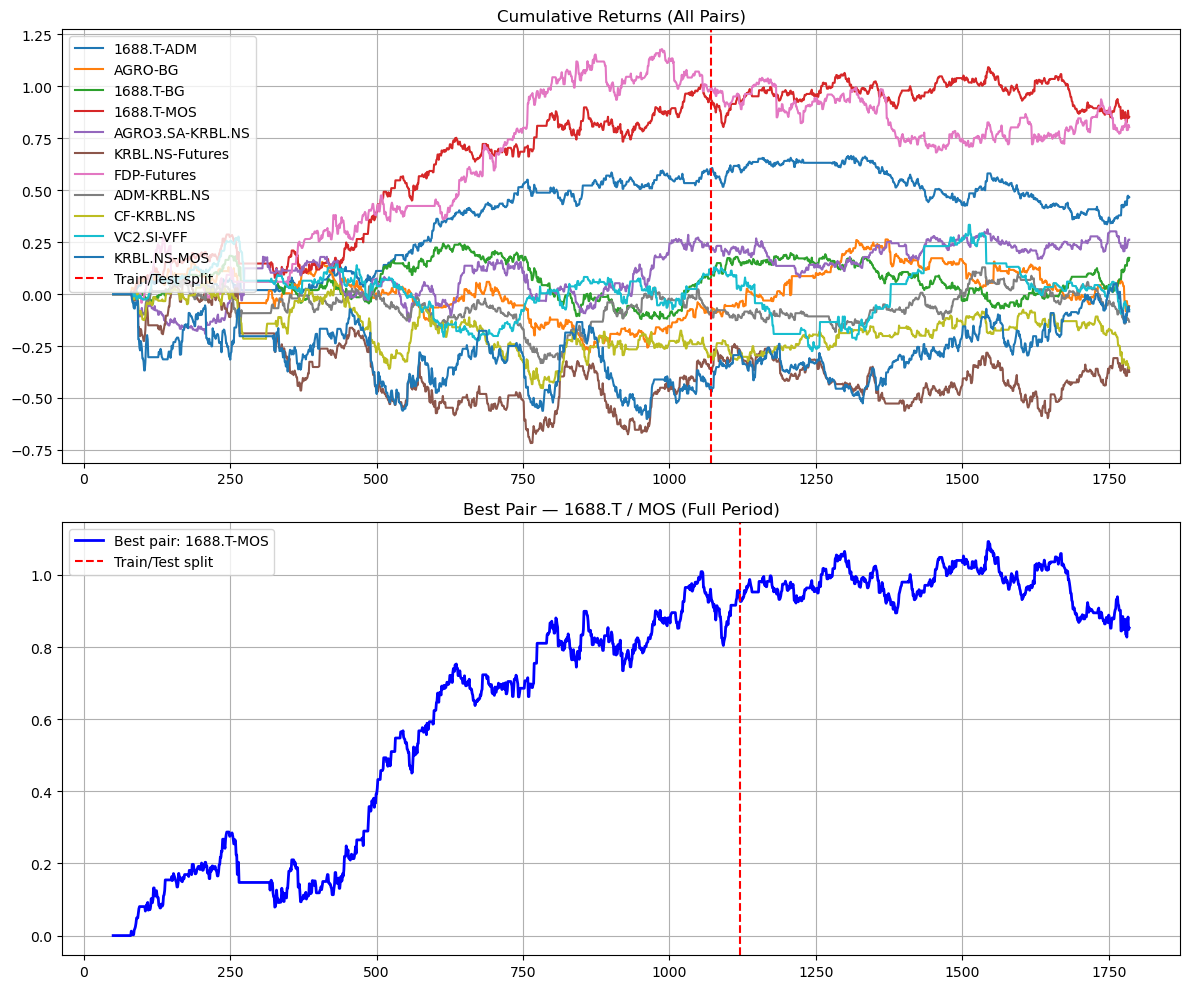


Best Pair: 1688.T / MOS
 Sharpe Ratio     : 0.6571671972571155
 Calmar Ratio     : 0.4674693223791191
  Annual Return    : 0.12386118933991735
  Annual Volatility: 0.1884774374875819
  Max Drawdown     : -0.2649611074145857


In [241]:
split_ratio = 0.6

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

best_sharpe = -np.inf
best_pair = None
best_all_returns = None

for pair, Y in pairs_Y.items():

    res = run_strategy(Y, lookback=50, L_v=30, k=1.5, threshold=0.7, transaction_cost=0.0, split=split_ratio)

    if res is None:
        continue
    
    returns = res["returns"]
    split_idx = res["split_index"]
    cum_returns = np.nancumsum(returns)
    time_index = Y.index[-len(cum_returns):]

    ax1.plot(time_index, cum_returns, label=f"{pair[0]}-{pair[1]}")
    split_date = Y.index[split_idx]

    # find best pair by Sharpe on full period
    sr = sharpe_ratio(returns)
    if sr > best_sharpe:
        best_sharpe = sr
        best_pair = pair
        best_all_returns = returns
        best_time_index = time_index
        best_split_idx = split_idx

ax1.axvline(x=split_date, color='red', linestyle='--', label='Train/Test split')
ax1.legend()
ax1.set_title("Cumulative Returns (All Pairs)")
ax1.grid()

best_cum = np.nancumsum(best_all_returns)
ax2.plot(best_time_index, best_cum, color='blue', linewidth=2,
         label=f"Best pair: {best_pair[0]}-{best_pair[1]}")
ax2.axvline(x=best_time_index[best_split_idx], color='red', linestyle='--', label='Train/Test split')
ax2.set_title(f"Best Pair — {best_pair[0]} / {best_pair[1]} (Full Period)")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

sr  = sharpe_ratio(best_all_returns)
cal = calmar_ratio(best_all_returns)
ar  = annual_return(best_all_returns)
av  = annual_volatility(best_all_returns)
mdd = max_drawdown(best_cum)

print(f"\nBest Pair: {best_pair[0]} / {best_pair[1]}")
print(f" Sharpe Ratio     : {sr}")
print(f" Calmar Ratio     : {cal}")
print(f"  Annual Return    : {ar}")
print(f"  Annual Volatility: {av}")
print(f"  Max Drawdown     : {mdd}")

From this initial approach, we obtain satisfactory results, with 5 out of 7 selected pairs generating positive cumulative returns. the red line indicate the separation between training and test data. 

**Verification of the Behaviour of Our Strategy**

Before moving on to the next step, we aim to verify that the opening and closing of positions are consistent with our expectations. The following visualization is designed to assess this behavior.

In [242]:
def plot_zscore_signals(res, threshold=0.7):

    z = pd.Series(res["z_score"])
    signal = pd.Series(res["signal_final"])

    long_points = z[signal==1]
    short_points = z[signal==-1]

    plt.figure(figsize=(12,5))

    plt.plot(z, color="black", linewidth=1)

    plt.axhline(threshold, linestyle="--", color="red",alpha=0.6)
    plt.axhline(-threshold,linestyle="--", color="red", alpha=0.6)

    plt.scatter(long_points.index, long_points,
                color="green", label="Long", s=30)

    plt.scatter(short_points.index, short_points,
                color="red",label="Short", s=30)

    plt.ylabel("Z-score")
    plt.xlabel("Index")
    plt.title("Z-score Trading Signals")
    plt.legend()

    plt.show()

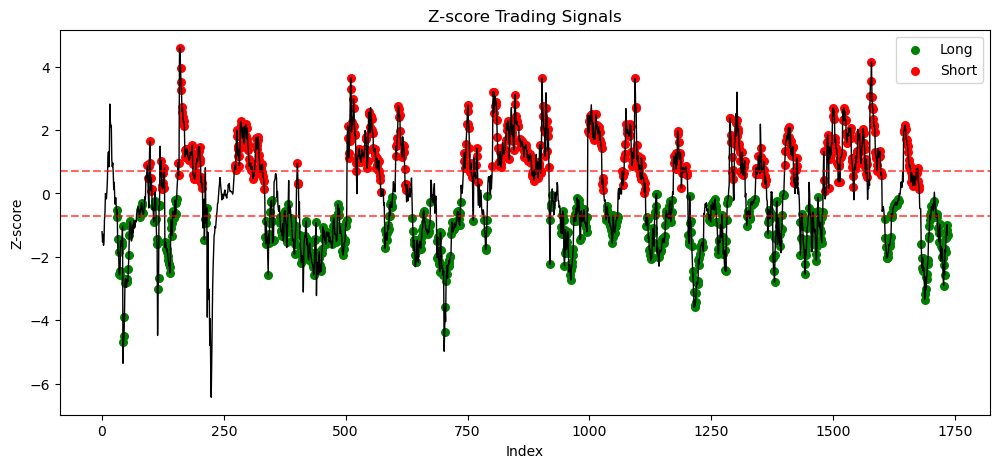

In [243]:
plot_zscore_signals(res)

The observed behavior is consistent with our expectations. Indeed, long positions are opened when the Z-score is low, while short positions are taken when it is high. No positions are held when the Z-score remains within the neutral range. Therefore, we can now proceed to the optimization of our strategy through a grid search over the parameters $(k, lookback, L_v, threshold)$.

#### 7.2 Strategy with Grid Search Parameter Optimization

We now aim to identify the optimal parameters for each pair in our trading strategy. To do so, we perform a grid search optimization based on the Sharpe ratio. In order to avoid data leakage, the Sharpe ratio is computed exclusively on the training dataset.

In [244]:
def evaluate_strategy_train(Y, params):

    res = run_strategy(
        Y,
        lookback=params["lookback"],
        L_v=params["L_v"],
        k=params["k"],
        threshold=params["threshold"],
        transaction_cost=0.0,
        split=0.6,
        base_stop=params["base_stop"],
        exit_band=params["exit_band"]
    )


    returns = res["returns"]
    split_idx = res["split_index"]

    train_returns = returns[:split_idx]

    sharpe = sharpe_ratio(train_returns)

    if np.isnan(sharpe):
        return -np.inf

    return sharpe

We define a grid of parameters to explore different configurations of the trading strategy. The grid includes variations of the lookback window, volatility window, entry threshold, and exit conditions. This parameter space will be used in a grid search procedure to identify the combination that maximizes the Sharpe ratio on the training set.

In [245]:
param_grid = {
    "lookback": [30, 50, 70],
    "L_v": [20, 30, 50],
    "k": [1.2],
    "threshold": [0.5, 0.7],
    "base_stop": [0.01],
    "exit_band": [0.0, 0.1]
}

We implement a grid search procedure to identify the optimal set of parameters for the trading strategy. All possible combinations of the predefined parameter grid are evaluated, and for each configuration, the Sharpe ratio is computed on the training dataset.

The function returns both the best-performing parameter set and a DataFrame summarizing all tested combinations, ranked by their Sharpe ratio. This allows for a comprehensive analysis of the sensitivity of the strategy to different parameter choices.

In [246]:
def optimize_parameters(Y, param_grid):

    keys = param_grid.keys()
    combinations = list(product(*param_grid.values()))

    best_score = -np.inf
    best_params = None
    results = []

    for values in combinations:

        params = dict(zip(keys, values))

        score = evaluate_strategy_train(Y, params)

        results.append({**params, "Sharpe": score})

        if score > best_score:
            best_score = score
            best_params = params

    results_df = pd.DataFrame(results).sort_values("Sharpe", ascending=False)

    return best_params, results_df

In [247]:
best_params_all = {}

for pair, Y in pairs_Y.items():

    print(f"Optimizing {pair}")

    best_params, results_df = optimize_parameters(Y, param_grid)

    best_params_all[pair] = best_params

    print("Best params:", best_params)
    print("Best Sharpe:", results_df.iloc[0]["Sharpe"])

Optimizing ('1688.T', 'ADM')
Best params: {'lookback': 50, 'L_v': 30, 'k': 1.2, 'threshold': 0.5, 'base_stop': 0.01, 'exit_band': 0.1}
Best Sharpe: 1.0940522901463714
Optimizing ('AGRO', 'BG')
Best params: {'lookback': 70, 'L_v': 50, 'k': 1.2, 'threshold': 0.7, 'base_stop': 0.01, 'exit_band': 0.0}
Best Sharpe: 0.4807500136561936
Optimizing ('1688.T', 'BG')
Best params: {'lookback': 70, 'L_v': 50, 'k': 1.2, 'threshold': 0.5, 'base_stop': 0.01, 'exit_band': 0.1}
Best Sharpe: 0.7008892323309401
Optimizing ('1688.T', 'MOS')
Best params: {'lookback': 70, 'L_v': 50, 'k': 1.2, 'threshold': 0.5, 'base_stop': 0.01, 'exit_band': 0.0}
Best Sharpe: 1.1014994242810296
Optimizing ('AGRO3.SA', 'KRBL.NS')
Best params: {'lookback': 50, 'L_v': 50, 'k': 1.2, 'threshold': 0.7, 'base_stop': 0.01, 'exit_band': 0.0}
Best Sharpe: 0.107266817008049
Optimizing ('KRBL.NS', 'Futures')
Best params: {'lookback': 70, 'L_v': 30, 'k': 1.2, 'threshold': 0.7, 'base_stop': 0.01, 'exit_band': 0.0}
Best Sharpe: 0.413621722

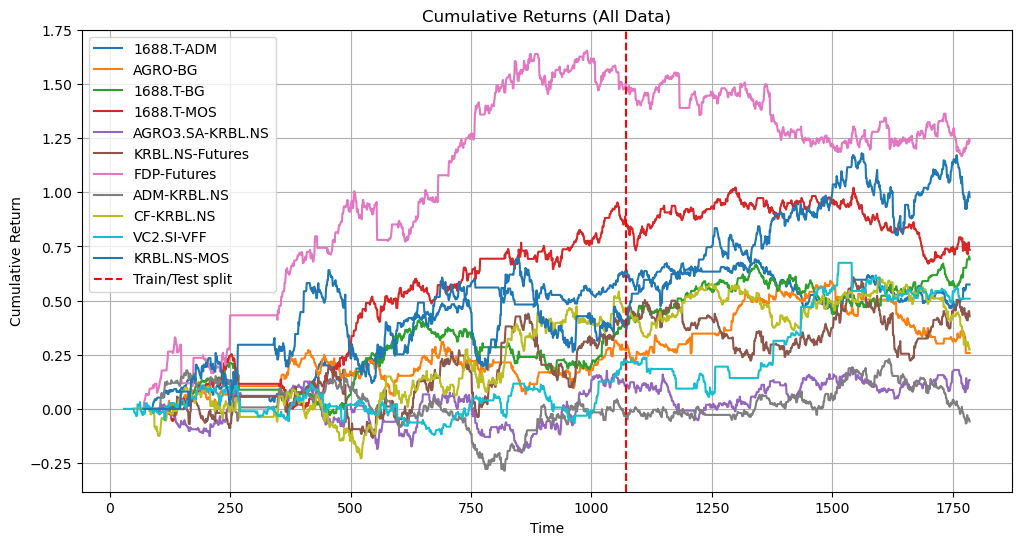

In [248]:
plt.figure(figsize=(12,6))

split_date = None 

for pair, Y in pairs_Y.items():

    params = best_params_all[pair]

    res = run_strategy(Y,lookback=params["lookback"],L_v=params["L_v"],k=params["k"],
        threshold=params["threshold"],transaction_cost=0, split=0.6,
        base_stop=params["base_stop"],exit_band=params["exit_band"])

    if res is None:
        continue
    returns = res["returns"]

    # cumulative returns
    cum_returns = np.nancumsum(returns)

    # align time index (important to avoid crash)
    time_index = Y.index[-len(cum_returns):]

    plt.plot(time_index, cum_returns, label=f"{pair[0]}-{pair[1]}")


    if split_date is None:
        split_idx = res["split_index"]
        split_date = Y.index[split_idx]

# red line train/test
plt.axvline(x=split_date, color='red', linestyle='--', label='Train/Test split')

plt.title("Cumulative Returns (All Data)")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid()

plt.show()

On this visualization we can see the different cumulatitive returns for the different pairs after greed search optimization, in the next part we will compare this new strategy to more classicl one (buy and hold etc).

#### 7.3 Comparison with Other Strategies

In this section, we compare the performance of several trading strategies:

- A baseline pairs trading strategy (without optimization)  
- The optimized pairs trading strategy  
- A pairs trading strategy applied to non-cointegrated pairs  
- A buy-and-hold strategy  
- A momentum-based trading strategy  

To ensure a fair and consistent comparison, we construct a portfolio for each strategy by aggregating returns across all considered pairs. This approach allows us to evaluate performance at the portfolio level rather than relying on individual pairs.

All strategies are evaluated over the same time period and using identical data, ensuring that differences in performance can be attributed solely to the strategy design.

C:\Users\mathi\AppData\Local\Temp\ipykernel_23532\975656829.py:8: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.vstack(aligned), axis=0)
C:\Users\mathi\AppData\Local\Temp\ipykernel_23532\975656829.py:56: RuntimeWarning: Mean of empty slice
  buy_hold_portfolio = np.nanmean(returns_assets, axis=1)
C:\Users\mathi\AppData\Local\Temp\ipykernel_23532\975656829.py:8: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.vstack(aligned), axis=0)


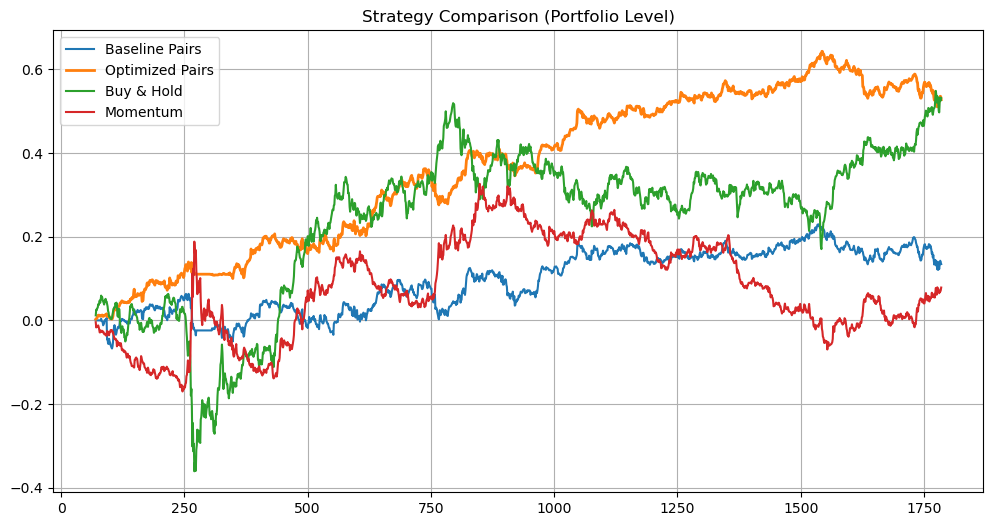

,Sharpe,Calmar,Annual Return,Volatility,Max Drawdown
Strategy,,,,,
Baseline,0.217,0.174,0.020,0.091,-0.114
Optimized,0.946,0.583,0.077,0.082,-0.133
Buy & Hold,0.452,0.184,0.078,0.172,-0.424
Momentum,0.082,0.029,0.012,0.140,-0.396


In [249]:
split_ratio = 0.6
freq = 252

# Compute the average return across all strategies (equal-weighted portfolio)
def portfolio_mean(returns_list):
    min_len = min(len(r) for r in returns_list)
    aligned = [r[-min_len:] for r in returns_list]
    return np.nanmean(np.vstack(aligned), axis=0)

# Baseline pairs trading (no parameters optimization)

baseline_returns_list = []

for pair, Y in pairs_Y.items():

    res = run_strategy(Y, lookback=50, L_v=30, k=1.5, threshold=0.7, transaction_cost=0,
        split=split_ratio)
    
    if res is None:
        continue

    baseline_returns_list.append(res["returns"])

baseline_portfolio = portfolio_mean(baseline_returns_list)

# OPtimized pairs trading

opt_returns_list = []

for pair, Y in pairs_Y.items():

    params = best_params_all[pair]

    res = run_strategy(
        Y,
        lookback=params["lookback"],
        L_v=params["L_v"],
        k=params["k"],
        threshold=params["threshold"],
        transaction_cost=0,
        split=split_ratio,
        base_stop=params["base_stop"],
        exit_band=params["exit_band"]
    )

    if res is None:
        continue

    opt_returns_list.append(res["returns"])

opt_portfolio = portfolio_mean(opt_returns_list)

# Buy & Hold strategy
returns_assets = log_prices.diff().values

buy_hold_portfolio = np.nanmean(returns_assets, axis=1)

# Momentum strategy

L_mom = 30
momentum_returns_list = []

for col in log_prices.columns:

    price = log_prices[col]
    returns = price.diff()

    signal = np.sign(returns.rolling(L_mom).sum())
    strat_returns = signal.shift(1) * returns

    momentum_returns_list.append(strat_returns.values)

momentum_portfolio = portfolio_mean(momentum_returns_list)

# align all the series
min_len = min(len(baseline_portfolio),len(opt_portfolio),len(buy_hold_portfolio),len(momentum_portfolio))

baseline_portfolio = baseline_portfolio[-min_len:]
opt_portfolio = opt_portfolio[-min_len:]
buy_hold_portfolio = buy_hold_portfolio[-min_len:]
momentum_portfolio = momentum_portfolio[-min_len:]

time_index = log_prices.index[-min_len:]

#Cumulative returns

cum_baseline = np.nancumsum(baseline_portfolio)
cum_opt = np.nancumsum(opt_portfolio)
cum_bh = np.nancumsum(buy_hold_portfolio)
cum_mom = np.nancumsum(momentum_portfolio)


plt.figure(figsize=(12,6))

plt.plot(time_index, cum_baseline, label="Baseline Pairs")
plt.plot(time_index, cum_opt, label="Optimized Pairs", linewidth=2)
plt.plot(time_index, cum_bh, label="Buy & Hold")
plt.plot(time_index, cum_mom, label="Momentum")

plt.legend()
plt.title("Strategy Comparison (Portfolio Level)")
plt.grid()
plt.show()

strategies = {
    "Baseline": baseline_portfolio,
    "Optimized": opt_portfolio,
    "Buy & Hold": buy_hold_portfolio,
    "Momentum": momentum_portfolio
}

metrics = []

for name, returns in strategies.items():

    cum_returns = np.nancumsum(returns)

    metrics.append({
        "Strategy": name,
        "Sharpe": sharpe_ratio(returns),
        "Calmar": calmar_ratio(returns),
        "Annual Return": annual_return(returns),
        "Volatility": annual_volatility(returns),
        "Max Drawdown": max_drawdown(cum_returns)
    })

metrics_df = pd.DataFrame(metrics).set_index("Strategy")

display(metrics_df.round(3))

## 8. Conclusion

The results highlight the strong performance of the optimized pairs trading strategy compared to the alternative approaches. In particular, it achieves the highest Sharpe ratio (0.946) and Calmar ratio (0.583), indicating superior risk-adjusted returns and better resilience to drawdowns.

While the buy-and-hold strategy exhibits a slightly higher annual return (0.078 vs. 0.077), it is associated with significantly higher volatility (0.172) and a much larger maximum drawdown (-0.424), reflecting a riskier profile. In contrast, the optimized strategy delivers a more balanced performance, combining relatively high returns (0.077) with lower volatility (0.082) and more controlled drawdowns (-0.133).

The baseline pairs trading strategy already provides moderate performance (Sharpe 0.217), confirming the relevance of the mean-reversion framework. However, the optimization step substantially improves both return and risk metrics, demonstrating the importance of parameter tuning.

Finally, the momentum strategy underperforms in this context, with lower returns (0.012) and weak risk-adjusted performance (Sharpe 0.082), suggesting that mean-reversion is more suitable for the considered assets.

Overall, these results validate the effectiveness of the optimized pairs trading approach, which offers a robust and well-balanced strategy compared to both passive and alternative active strategies.